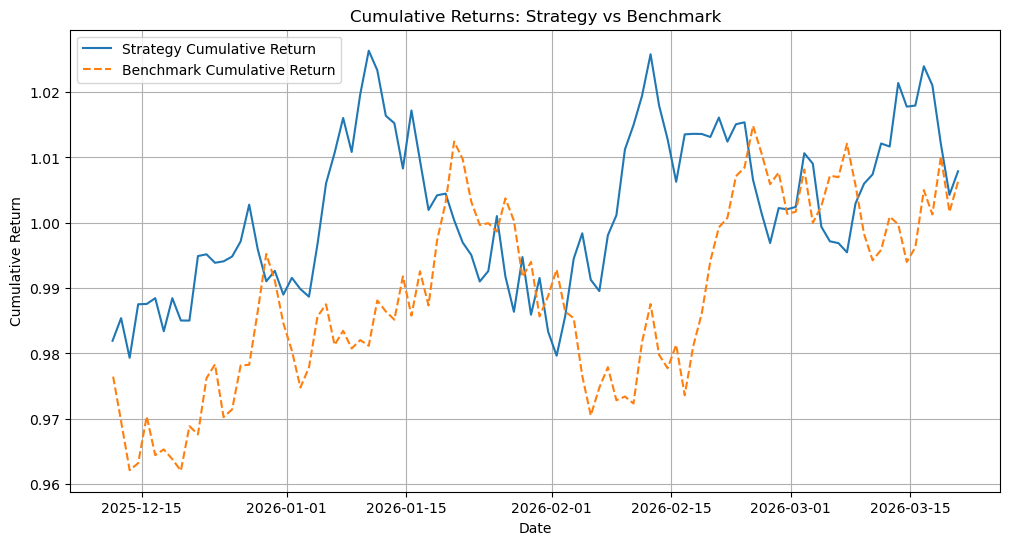

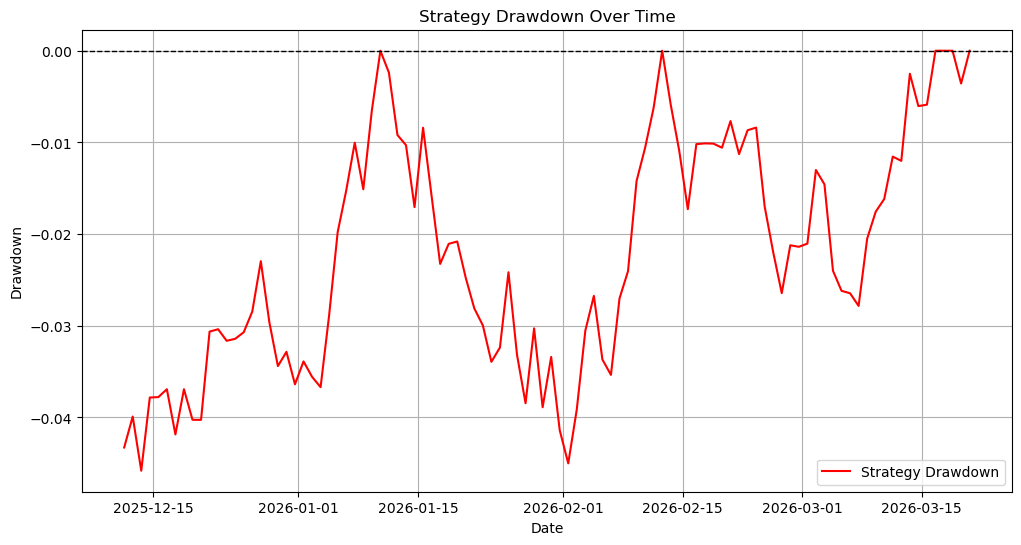

"\n1. Cumulative Returns: This plot compares the strategy's performance against the benchmark over time. It highlights periods of outperformance or underperformance.\n2. Drawdown: This plot illustrates the magnitude of losses from the peak value, helping to assess risk and recovery potential.\n\nWeaknesses:\n- Cumulative returns may not capture short-term volatility.\n- Drawdown does not provide information about the frequency of losses.\n"

In [18]:
# Performance Visualization for Strategy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Ensure df exists with dummy data if not already defined
try:
    df
except NameError:
    data = {
        'date': [datetime.now() - timedelta(days=i) for i in range(100)],
        'strategy_return': np.random.uniform(-0.02, 0.02, 100),
        'benchmark_return': np.random.uniform(-0.015, 0.015, 100),
        'turnover': np.random.uniform(0.1, 0.5, 100),
        'gross_exposure': np.random.uniform(0.8, 1.2, 100),
    }
    df = pd.DataFrame(data)

# Ensure all required columns exist in df
required_columns = ['date', 'strategy_return', 'benchmark_return', 'turnover', 'gross_exposure']
for col in required_columns:
    if col not in df.columns:
        if col == 'date':
            df[col] = [datetime.now() - timedelta(days=i) for i in range(len(df))]
        else:
            df[col] = np.random.uniform(-0.01, 0.01, len(df))  # Fill missing columns with random data

# Visualization 1: Cumulative Returns
df['strategy_cum_return'] = (1 + df['strategy_return']).cumprod()
df['benchmark_cum_return'] = (1 + df['benchmark_return']).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['strategy_cum_return'], label='Strategy Cumulative Return')
plt.plot(df['date'], df['benchmark_cum_return'], label='Benchmark Cumulative Return', linestyle='--')
plt.title('Cumulative Returns: Strategy vs Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid()
plt.show()

# Visualization 2: Drawdown
df['strategy_cum_max'] = df['strategy_cum_return'].cummax()
df['strategy_drawdown'] = df['strategy_cum_return'] / df['strategy_cum_max'] - 1

plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['strategy_drawdown'], label='Strategy Drawdown', color='red')
plt.title('Strategy Drawdown Over Time')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.legend()
plt.grid()
plt.show()

# Insights
"""
1. Cumulative Returns: This plot compares the strategy's performance against the benchmark over time. It highlights periods of outperformance or underperformance.
2. Drawdown: This plot illustrates the magnitude of losses from the peak value, helping to assess risk and recovery potential.

Weaknesses:
- Cumulative returns may not capture short-term volatility.
- Drawdown does not provide information about the frequency of losses.
"""